In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')

In [2]:
df.head()

,Weight,Height
0,52,158
1,58,162
2,61,165
3,55,160
4,72,175


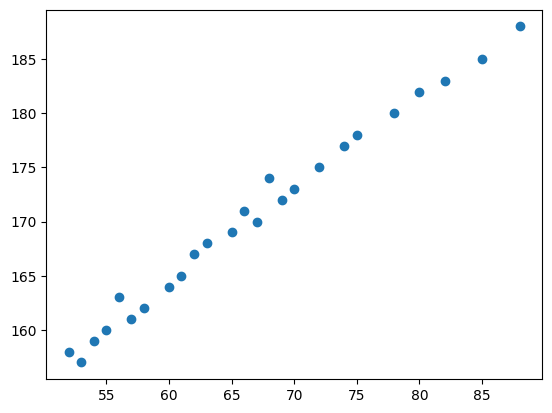

In [3]:
plt.scatter(df['Weight'], df['Height'])

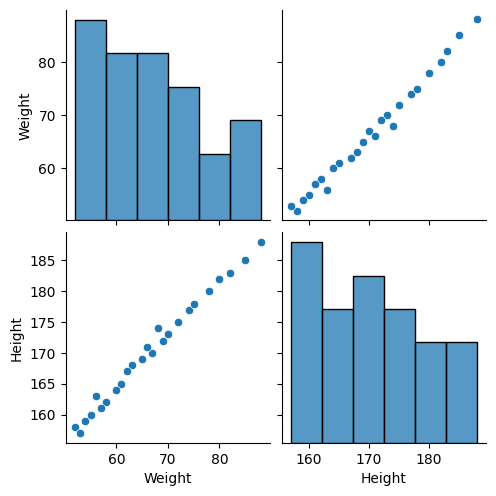

In [4]:
import seaborn as sns

sns.pairplot(df)

In [5]:
df.corr()

,Weight,Height
Weight,1.000000,0.994656
Height,0.994656,1.000000


<Axes: >

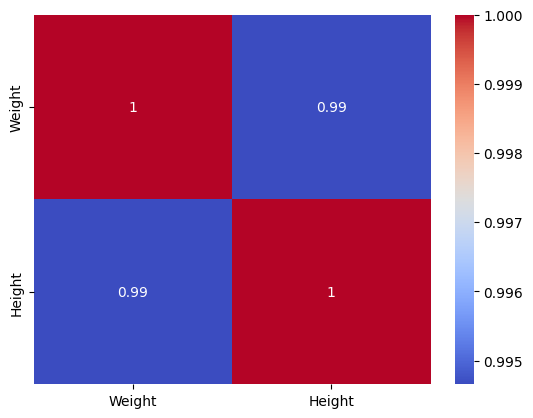

In [7]:
# correlation plot
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

In [9]:
# Independent and dependent Variables

x = df[['Weight']]      ## must be a 2D array because independent feature must be in 2D array
y = df['Height']        ## can be a 1D array because dependent feature must be in 1D array

In [10]:
## Train and test split 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [11]:
x_train.shape

(18, 1)

In [13]:
### standardization and normalization of data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [15]:
### Apply Linear Regression

from sklearn.linear_model import LinearRegression

regression = LinearRegression(n_jobs = -1)

regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
regression.coef_

array([9.08790521])

In [18]:
regression.intercept_

np.float64(170.94444444444446)

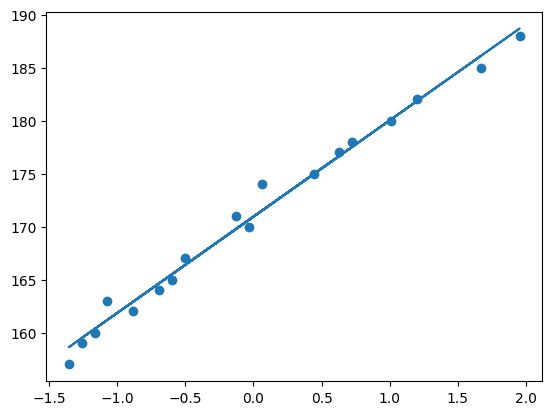

In [19]:
## plot training data and regression line

plt.scatter(x_train, y_train)

plt.plot(x_train, regression.predict(x_train))

In [20]:
### prediction for test data

y_pred = regression.predict(x_test)

In [21]:
y_pred

array([173.23551804, 172.37636544, 157.77077127, 183.54534922,
       162.06653426, 167.22144985, 168.93975505])

In [22]:
### Performance metrices

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

score = r2_score(y_test, y_pred)


print(mse, mae, score)

0.32776234225055656 0.4702558282498736 0.9943608304879644


In [23]:
regression.predict(scaler.transform([[78]]))

c:\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([180.10873883])